In [77]:
# trying to set up a CVX problem
import cvxpy
import numpy as np
from hsa_hopper.kinematics import *
from hsa_hopper.collocation import interp_covector
from scipy.sparse import bsr_array
import pandas as pd

class RegDiffer:
    def __init__(self):
        pass
    """
    Create a sparse linear operator that evaluates C1 continuity
    on a quadratic spline of the motor angle measurements.
    """ 
    def _eq_const_sparse_op(self, df):
        t = df['t_s'].to_numpy()
        N = t.size
        rows = 2*(N-2)
        cols = 3*(N-1)
        nnz = 6*(2*(N-2))
        data = np.zeros(nnz)
        rowptr = np.zeros(nnz, dtype=np.int32)
        colptr = np.zeros(nnz, dtype=np.int32)

        for i in range(1,N-1):
            t0 = interp_covector(t[i],t[i-1],t[i],3)
            dt0 = interp_covector(t[i],t[i-1],t[i],3,ord=1)
            t1 = interp_covector(t[i],t[i],t[i+1],3)
            dt1 = interp_covector(t[i],t[i],t[i+1],3,ord=1)
            for j in range(3):

                row = np.ravel_multi_index((i-1,0),(N-2,2),order='C')
                col = np.ravel_multi_index((i-1,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,0,0),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = -t0[0,j]

                col = np.ravel_multi_index((i,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,1,0),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = t1[0,j]

                row = np.ravel_multi_index((i-1,1),(N-2,2),order='C')
                col = np.ravel_multi_index((i-1,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,0,1),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = -dt0[0,j]

                col = np.ravel_multi_index((i,j),(N-1,3),order='C')
                idx = np.ravel_multi_index((i-1,j,1,1),(N-2,3,2,2),order='C')
                rowptr[idx] = row
                colptr[idx] = col
                data[idx] = dt1[0,j]
        return bsr_array((data,(rowptr,colptr)),shape=(rows,cols))

    """
    Creates a sparse linear operator that evaluates the spline at each
    time step. The keywork argument ord determines the order of differentiation.
    """
    def _interp_sparse_op(self, df, ord=0):
        t = df['t_s'].to_numpy()
        rows = t.size
        cols = 3*(t.size-1)
        nnz = (3-ord)*t.size
        data = np.zeros(nnz)
        rowptr = np.zeros(nnz, dtype=np.int32)
        colptr = np.zeros(nnz, dtype=np.int32)
        for i in range(t.size-1):
            if i == 0:
                covec = interp_covector(t[0],t[0],t[1],3,ord=ord)
                interp_idx = (3-ord)*[0], list(range(ord,3))
                col_idx = np.ravel_multi_index(interp_idx, (t.size-1,3), order='C')
                data[:(3-ord)] = covec[0,ord:]
                rowptr[:(3-ord)] = 0
                colptr[:(3-ord)] = col_idx

                covec = interp_covector(t[1],t[0],t[1],3,ord=ord)
                col_idx = np.ravel_multi_index(interp_idx, (t.size-1,3), order='C')
                data[(3-ord):2*(3-ord)] = covec[0,ord:]
                rowptr[(3-ord):2*(3-ord)] = 1
                colptr[(3-ord):2*(3-ord)] = col_idx
            else:
                covec = interp_covector(t[i+1],t[i],t[i+1],3,ord=ord)
                interp_idx = (3-ord)*[i], list(range(ord,3))
                col_idx = np.ravel_multi_index(interp_idx, (t.size-1,3), order='C')
                data[(3-ord)*(i+1):(3-ord)*(i+2)] = covec[0,ord:]
                rowptr[(3-ord)*(i+1):(3-ord)*(i+2)] = i+1
                colptr[(3-ord)*(i+1):(3-ord)*(i+2)] = col_idx
        return bsr_array((data,(rowptr,colptr)),shape=(rows,cols))
    
    def diff_x(self, df, weights):
        eq_const_op = self._eq_const_sparse_op(df)
        pos_linop = self._interp_sparse_op(df,ord=0)
        vel_linop = self._interp_sparse_op(df,ord=1)
        acc_linop = self._interp_sparse_op(df,ord=2)
        x = df['x_rad'].to_numpy()
        x0 = x[0]
        t = df['t_s'].to_numpy()
        tdiff = np.diff(t)
        vars = cvxpy.Variable(3*(t.size-1))

        pos = pos_linop@vars
        pos_err = pos-(x-x0)
        acc = acc_linop@vars
        acc_abs = cvxpy.abs(acc)
        acc_sqr = cvxpy.power(acc,2)
        integrate = lambda f,dt: cvxpy.sum(cvxpy.multiply(f[:-1]+f[1:],dt/2))

        pos_cost = cvxpy.sum_squares(pos_err)

        if weights[1] == 0:
            l1_cost = 0
        else:
            l1_cost = cvxpy.sum(integrate(acc_abs,tdiff))
        if weights[2] == 0:
            l2_cost = 0
        else:
            l2_cost = integrate(acc_sqr,tdiff) 
        cost = weights[0]*(pos_cost) + weights[1]*l1_cost + weights[2]*l2_cost
        constraints = [eq_const_op@vars == 0]
        prob = cvxpy.Problem(cvxpy.Minimize(cost), constraints)

        if prob.is_dcp():
            print('Solving regularized differentiation problem')
            prob.solve()
            coeffs = vars.value
            pos = pos_linop@coeffs
            # add back x0
            pos += x0
            vel = vel_linop@coeffs
            acc = acc_linop@coeffs
            return pos, vel, acc
        else:
            print(f'Differentiation problem is not DCP?')
            return None, None, None

    def smooth_tau(self, df, weights):
        tau = df['torque'].to_numpy()
        t = df['t_s'].to_numpy()
        vars = cvxpy.Variable(t.size)
        tau0 = tau[0]
        errors = vars - (tau-tau0)
        tau_diffs = vars[:-1]-vars[1:]

        square_errors = cvxpy.power(errors,2)
        sos_errors = cvxpy.sum(square_errors)
        if weights[1] == 0:
            l1_cost = 0
        else:
            l1_cost = cvxpy.sum(cvxpy.abs(tau_diffs))
        if weights[2] == 0:
            l2_cost = 0
        else:
            l2_cost = cvxpy.sum(cvxpy.power(tau_diffs,2))

        cost = weights[0]*sos_errors+weights[1]*l1_cost + weights[2]*l2_cost
        prob = cvxpy.Problem(cvxpy.Minimize(cost))

        if prob.is_dcp():
            prob.solve()
            return vars.value + tau0

In [78]:
import os
import yaml
from hsa_hopper.kinematics import *
from hsa_hopper.controller import HopController
kin_params = KinematicParameters(.07,.15,.3,-.005)
root_dir = r'C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\aim2\4_28\linear_model'
differ = RegDiffer()
for experiment_path in os.listdir(root_dir):
    experiment_dir = os.path.join(root_dir, experiment_path)
    for trial_path in os.listdir(experiment_dir):
        trial_dir = os.path.join(experiment_dir, trial_path)
        if os.path.isfile(trial_path):
            continue
        hop_frames = []
        hop_idx = []
        for file_path in os.listdir(trial_dir):
            if 'hop' not in file_path:
                continue
            idx = int(file_path.split('_')[1][:-4])
            print(f'Processing hop #{idx} of trial {trial_path} in category {experiment_path}')
            df = pd.read_csv(os.path.join(trial_dir,file_path))
            if len(df) <= 50:
                print(f'hop {idx} is too short, possible controller data. Skipping this frame.')
                continue 
            x_raw = df['x_rad'].to_numpy(copy=True)
            tau_raw = df['torque'].to_numpy(copy=True)
            x, xdot, xddot = differ.diff_x(df, [1,1e-5,1e-6])
            tau = differ.smooth_tau(df,[1,0,10])
            fk,jac,hess = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
            df['x_raw'] = x_raw
            df['x_rad'] = x
            df['torque_raw'] = tau_raw
            df['torque'] = tau
            df['xdot'] = xdot
            df['xddot'] = xddot
            df['y_m'] = fk[0]
            df['ydot'] = jac[0]*xdot
            df['yddot'] = jac[0]*xddot + xdot*hess[0]*xdot
            df['l_m'] = fk[1]
            df['ldot'] = jac[1]*xdot
            df['lddot'] = jac[1]*xddot + xdot*hess[1]*xdot
            df['dydx'] = jac[0]
            df['dldx'] = jac[1]
            df['d2yd2x'] = hess[0]
            df['d2ld2x'] = hess[1]
            hop_idx.append(idx)
            df['hop_idx'] = idx
            hop_frames.append(df)
            # filter stance data
            # unique_modes = df['mode'].unique()
            # if len(unique_modes) == 3:
            #     frame = (df['mode'] == 2) | (df['mode'] == 3)
            # else:
            #     frame = (df['mode'] == HopController._STANCE) | (df['mode'] == HopController._STARTUP)
            # if sum(frame) <= 10:
            #     print(f'Stance phase of hop {idx} is too short, possible controller data. Skipping this frame.')
            #     continue 
            # x_raw = df.loc[frame,'x_rad'].to_numpy(copy=True)
            # tau_raw = df.loc[frame,'torque'].to_numpy(copy=True)
            # x, xdot, xddot = differ.diff_x(df.loc[frame,:], [1,1e-4,1e-6])
            # tau = differ.smooth_tau(df.loc[frame,:], [1,0,100])
            # fk,jac,hess = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
            # df.loc[frame,'x_raw'] = x_raw
            # df.loc[frame,'x_rad'] = x
            # df.loc[frame,'xdot'] = xdot
            # df.loc[frame,'xddot'] = xddot
            # df.loc[frame,'torque'] = tau
            # df.loc[frame,'torque_raw'] = tau_raw
            # df.loc[frame,'y_m'] = fk[0]
            # df.loc[frame,'ydot'] = jac[0]*xdot
            # df.loc[frame,'yddot'] = jac[0]*xddot + xdot*hess[0]*xdot
            # df.loc[frame,'l_m'] = fk[1]
            # df.loc[frame,'ldot'] = jac[1]*xdot
            # df.loc[frame,'lddot'] = jac[1]*xddot + xdot*hess[1]*xdot
            # df.loc[frame,'dydx'] = jac[0]
            # df.loc[frame,'dldx'] = jac[1]
            # df.loc[frame,'d2yd2x'] = hess[0]
            # df.loc[frame,'d2ld2x'] = hess[1]

            # frame = (df['mode'] == HopController._FLIGHT)
            # if sum(frame) <= 10:
            #     print(f'Flight phase of hop {idx} is too short, possible controller data. Skipping this frame.')
            #     continue
            # x_raw = df.loc[frame,'x_rad'].to_numpy(copy=True)
            # x_raw = df.loc[frame,'x_rad'].to_numpy(copy=True)
            # tau_raw = df.loc[frame,'torque'].to_numpy(copy=True)
            # x, xdot, xddot = differ.diff_x(df.loc[frame,:], [1,1e-4,1e-6])
            # tau = differ.smooth_tau(df.loc[frame,:], [1,0,100])
            # fk,jac,hess = forward_kinematics(kin_params,x,jacobian=True,hessian=True)
            # df.loc[frame, 'x_raw'] = x_raw
            # df.loc[frame, 'x_rad'] = x
            # df.loc[frame, 'xdot'] = xdot
            # df.loc[frame, 'xddot'] = xddot
            # df.loc[frame, 'torque'] = tau
            # df.loc[frame, 'torque_raw'] = tau_raw
            # df.loc[frame, 'y_m'] = fk[0]
            # df.loc[frame, 'ydot'] = jac[0]*xdot
            # df.loc[frame, 'yddot'] = jac[0]*xddot + xdot*hess[0]*xdot
            # df.loc[frame, 'l_m'] = fk[1]
            # df.loc[frame, 'ldot'] = jac[1]*xdot
            # df.loc[frame, 'lddot'] = jac[1]*xddot + xdot*hess[1]*xdot
            # df.loc[frame, 'dydx'] = jac[0]
            # df.loc[frame, 'dldx'] = jac[1]
            # df.loc[frame, 'd2yd2x'] = hess[0]
            # df.loc[frame, 'd2ld2x'] = hess[1]
            # hop_idx.append(idx)
            # df['hop_idx'] = idx
            # hop_frames.append(df)
        trial_df = pd.concat([hop_frames[i] for i in np.argsort(hop_idx)])
        # print(f'Processing trial {trial_path} of experiment {experiment_path}')
        # x_raw = trial_df['x_rad'].to_numpy(copy=True)
        # tau_raw = trial_df['torque'].to_numpy(copy=True)
        # x, xdot, xddot = differ.diff_x(trial_df, [1,0,1e-3])
        # tau = differ.smooth_tau(trial_df, [1,0,100])
        # print(f'Data smoothing complete')
        trial_df.to_csv(os.path.join(trial_dir, 'data.csv'))

Processing hop #0 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #1 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #10 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #11 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #12 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #13 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #14 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #15 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #16 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing hop #17 of trial 0deg in category hsa_1700g
Solving regularized differentiation problem
Processing h

In [79]:
print(experiment_dir)

C:\Users\Joseph Sullivan\Documents\hsa_hopper_control\data\aim2\4_28\linear_model\hsa_1700g


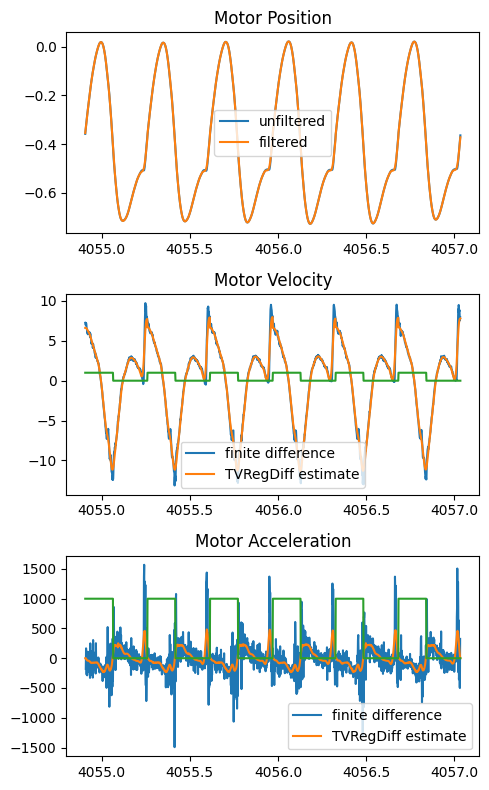

In [80]:
from matplotlib import pyplot as plt
frame = (30 <= trial_df['hop_idx']) & (trial_df['hop_idx'] <= 35)
x = trial_df.loc[frame,'x_rad'].to_numpy()
x_raw = trial_df.loc[frame,'x_raw'].to_numpy()
xdot = trial_df.loc[frame,'xdot'].to_numpy()
xddot = trial_df.loc[frame,'xddot'].to_numpy()
t = trial_df.loc[frame,'t_s'].to_numpy()
mode = trial_df.loc[frame,'mode'].to_numpy()
fig,axs = plt.subplots(nrows=3,figsize=(5,8))
axs[0].plot(t,x_raw,label='unfiltered')
axs[0].plot(t,x,label='filtered')
# axs[0].plot(t,mode,label='mode')
axs[0].legend()
axs[0].set_title('Motor Position')
axs[1].plot(t[:-1],np.diff(x_raw)/np.diff(t),label='finite difference')
axs[1].plot(t,xdot,label='TVRegDiff estimate')
axs[1].plot(t,mode-1)
axs[1].set_title('Motor Velocity')
axs[1].legend()
axs[2].plot(t[1:-1],np.diff(np.diff(x_raw)/np.diff(t))/np.diff(t[1:]),label='finite difference')
axs[2].plot(t,xddot,label='TVRegDiff estimate')
axs[2].plot(t,(mode-1)*1000)
axs[2].set_title('Motor Acceleration')
axs[2].legend()
fig.tight_layout()
fig.savefig('tvregdiff.png')

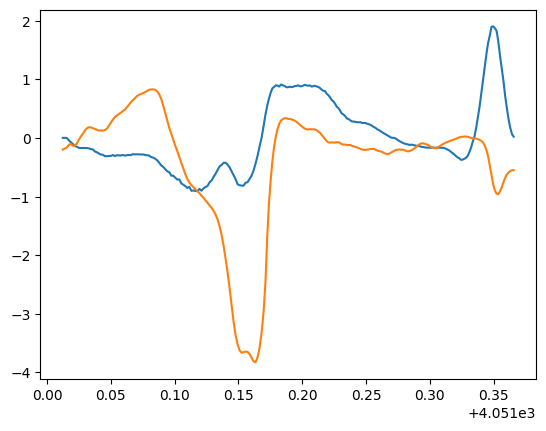

In [81]:
frame = trial_df['hop_idx'] == 19
xdot = trial_df.loc[frame,'xdot']
xddot = trial_df.loc[frame,'xddot']
torque = trial_df.loc[frame,'torque']
t = trial_df.loc[frame,'t_s']
plt.plot(t,4e-3*xddot)
plt.plot(t,torque)
# plt.plot(t,torque)
# plt.plot(t,x-x_raw)

In [82]:
for idx in trial_df['hop_idx'].unique():
    # find maximum acceleration in stance
    frame = (trial_df['hop_idx'] == idx) & (trial_df['mode'] == HopController._STANCE)
    lddot = trial_df.loc[frame, 'lddot'].to_numpy()
    stance_jerk = np.diff(lddot)
    stance_max_acc_idx = np.argmax(stance_jerk)
    frame = (trial_df['hop_idx'] == idx) & (trial_df['mode'] == HopController._FLIGHT)
    lddot = trial_df.loc[frame, 'lddot'].to_numpy()
    flight_jerk = np.diff(lddot)
    flight_max_acc_idx = np.argmax(stance_jerk)
    print((idx,stance_jerk[stance_max_acc_idx],flight_jerk[flight_max_acc_idx]))

(0, 3.330020601182273, -0.1378005892184242)
(1, 3.603447136271824, 0.04241316017710206)
(2, 3.621333786139486, -0.004674224121519632)
(3, 3.1454397677829897, 0.04874606875983867)
(4, 3.7157444901481567, -0.00777570112208581)
(5, 3.8106835217854322, 0.11244310355564391)
(6, 3.5672212771915084, 0.03168707217836442)
(7, 3.554852538429567, 0.034158751788853525)
(8, 3.919938112174081, 0.04350794853447271)
(9, 3.610614755112578, -0.02060629252032875)
(10, 4.087450323081677, -0.03626582298454473)
(11, 3.597062605428341, -0.062071616635269056)
(12, 3.5848772573053327, -0.0041425666789525195)
(13, 3.734716830666171, 0.22164851696930965)
(14, 3.8088699568052826, -0.30615493986876097)
(15, 4.448657854115393, 0.13933063013666214)
(16, 4.135269390329973, 0.15529748069393223)
(17, 4.120208719676611, -0.21078029367087758)
(18, 3.8017900511133176, 0.1508958603867403)
(19, 4.192481487485599, 0.08400705006187348)
(20, 4.056979093161925, -0.021198318913359326)
(21, 4.073332415778761, -0.16222951605499203

In [83]:
liftoff_vel = []
touchdown_vel = []
x = trial_df['x_raw'].to_numpy()
t = trial_df['t_s'].to_numpy()
dydx = trial_df['dydx'].to_numpy()
mode = trial_df['mode'].to_numpy()
hop_idx = trial_df['hop_idx'].to_numpy()
for idx in trial_df['hop_idx'].unique():
    df = trial_df.loc[frame,:]
    t = df['t_s'].to_numpy()
    y = df['y_m'].to_numpy()
    ydot = df['ydot'].to_numpy()
    mode = df['mode'].to_numpy()
    frame = trial_df['hop_idx'] == idx
    flight_start = next(i for i in range(len(mode)) if mode[i] == 1)
    touchdown_vel.append(ydot[0])
    # liftoff_vel.append(ydot[flight_start])
    liftoff_vel.append(ydot[flight_start])
print(np.average(touchdown_vel))
print(np.average(liftoff_vel)**2 / (2*9.81))
print(liftoff_vel)

-0.4914929492360766
0.036871831754869036
[0.8723576743388816, 0.8277932272696062, 0.8543214855011004, 0.8408608627883766, 0.8580330319937557, 0.8499301161145448, 0.8418969220127872, 0.8625276247575406, 0.8337960757607358, 0.8431620495110652, 0.835869139009665, 0.8470345667790506, 0.840981033505755, 0.838576612552464, 0.8415287579451068, 0.8308911778548782, 0.8581591452863726, 0.8526169662768168, 0.8444123906578379, 0.8484328494530201, 0.8501140523805378, 0.8512350170756265, 0.8451947428965476, 0.8412237977146756, 0.84698858760955, 0.8430674701219969, 0.8496336037915938, 0.8473981279939921, 0.8507292613280351, 0.8556010414767043, 0.852499394761786, 0.8448585176483502, 0.8487561136623446, 0.8526253194908162, 0.8702503903178579, 0.8656552885670887, 0.8430971268701433, 0.8530592827336844, 0.8478496009878845, 0.847068500368104, 0.8442521884378494, 0.8701775323470406, 0.8680325401953773, 0.8595492887494517, 0.839230728087472, 0.8557111372251267, 0.8503339768355977, 0.8533534083740518, 0.8480